# Restaurant Food Demand Prediction and Inventory Planning Using Machine Learning

### Project Type
Machine Learning / Data Science

### Objective
To predict future food demand using historical order data, meal characteristics, pricing, promotional activities, and fulfillment center information.

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- XGBoost
- Jupyter Notebook

### Machine Learning Models
1. Linear Regression
2. Random Forest Regressor
3. XGBoost Regressor

### Best Performing Model
Random Forest Regressor

### Best Model Performance
- MAE: 88.32
- RMSE: 196.48
- R² Score: 0.714

1. Project Introduction
2. Problem Statement
3. Objectives
4. Dataset Description
5. Data Loading
6. Data Understanding
7. Data Preprocessing
8. Data Integration
9. Exploratory Data Analysis
10. Feature Engineering
11. Feature Encoding
12. Train-Validation Split
13. Machine Learning Models
    - Linear Regression
    - Random Forest
    - XGBoost
14. Model Evaluation
15. Model Comparison
16. Feature Importance
17. Future Demand Prediction
18. Inventory Recommendation
19. Conclusion
20. Future Scope
21. Limitations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [3]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test_QoiMO9B.csv")
meal = pd.read_csv("meal_info.csv")
center = pd.read_csv("fulfilment_center_info.csv")

In [5]:
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)
print("Meal Shape:", meal.shape)
print("Center Shape:", center.shape)

Train Shape: (456548, 9)
Test Shape: (32573, 8)
Meal Shape: (51, 3)
Center Shape: (77, 5)


In [7]:
train.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     456548 non-null  int64  
 1   week                   456548 non-null  int64  
 2   center_id              456548 non-null  int64  
 3   meal_id                456548 non-null  int64  
 4   checkout_price         456548 non-null  float64
 5   base_price             456548 non-null  float64
 6   emailer_for_promotion  456548 non-null  int64  
 7   homepage_featured      456548 non-null  int64  
 8   num_orders             456548 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 31.3 MB


In [11]:
train.describe()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
count,4.565480e+05,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.00000,456548.000000
mean,1.250096e+06,74.768771,82.105796,2024.337458,332.238933,354.156627,0.081152,0.10920,261.872760
std,1.443548e+05,41.524956,45.975046,547.420920,152.939723,160.715914,0.273069,0.31189,395.922798
min,1.000000e+06,1.000000,10.000000,1062.000000,2.970000,55.350000,0.000000,0.00000,13.000000
25%,1.124999e+06,39.000000,43.000000,1558.000000,228.950000,243.500000,0.000000,0.00000,54.000000
50%,1.250184e+06,76.000000,76.000000,1993.000000,296.820000,310.460000,0.000000,0.00000,136.000000
75%,1.375140e+06,111.000000,110.000000,2539.000000,445.230000,458.870000,0.000000,0.00000,324.000000
max,1.499999e+06,145.000000,186.000000,2956.000000,866.270000,866.270000,1.000000,1.00000,24299.000000


In [13]:
train.isnull().sum()

id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
dtype: int64

In [15]:
train.duplicated().sum()

0

In [17]:
df = train.merge(
    meal,
    on="meal_id",
    how="left"
)

df = df.merge(
    center,
    on="center_id",
    how="left"
)

In [19]:
df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine,city_code,region_code,center_type,op_area
0,1379560,1,55,1885,136.83,152.29,0,0,177,Beverages,Thai,647,56,TYPE_C,2.0
1,1466964,1,55,1993,136.83,135.83,0,0,270,Beverages,Thai,647,56,TYPE_C,2.0
2,1346989,1,55,2539,134.86,135.86,0,0,189,Beverages,Thai,647,56,TYPE_C,2.0
3,1338232,1,55,2139,339.50,437.53,0,0,54,Beverages,Indian,647,56,TYPE_C,2.0
4,1448490,1,55,2631,243.50,242.50,0,0,40,Beverages,Indian,647,56,TYPE_C,2.0


In [21]:
df.shape

(456548, 15)

In [23]:
df.columns

Index(['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price',
       'emailer_for_promotion', 'homepage_featured', 'num_orders', 'category',
       'cuisine', 'city_code', 'region_code', 'center_type', 'op_area'],
      dtype='object')

In [25]:
print("MEAL DATA")
display(meal.head())

print("\nCENTER DATA")
display(center.head())

print("\nTEST DATA")
display(test.head())

MEAL DATA


,meal_id,category,cuisine
0,1885,Beverages,Thai
1,1993,Beverages,Thai
2,2539,Beverages,Thai
3,1248,Beverages,Indian
4,2631,Beverages,Indian



CENTER DATA


,center_id,city_code,region_code,center_type,op_area
0,11,679,56,TYPE_A,3.7
1,13,590,56,TYPE_B,6.7
2,124,590,56,TYPE_C,4.0
3,66,648,34,TYPE_A,4.1
4,94,632,34,TYPE_C,3.6



TEST DATA


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured
0,1028232,146,55,1885,158.11,159.11,0,0
1,1127204,146,55,1993,160.11,159.11,0,0
2,1212707,146,55,2539,157.14,159.14,0,0
3,1082698,146,55,2631,162.02,162.02,0,0
4,1400926,146,55,1248,163.93,163.93,0,0


In [27]:
print("Meal columns:")
print(meal.columns.tolist())

print("\nCenter columns:")
print(center.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

Meal columns:
['meal_id', 'category', 'cuisine']

Center columns:
['center_id', 'city_code', 'region_code', 'center_type', 'op_area']

Test columns:
['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured']


In [29]:
print("Shape:", train.shape)

print("\nMissing Values:")
print(train.isnull().sum())

print("\nDuplicate Rows:")
print(train.duplicated().sum())

Shape: (456548, 9)

Missing Values:
id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
dtype: int64

Duplicate Rows:
0


In [31]:
df = train.merge(
    meal,
    on="meal_id",
    how="left"
)

df = df.merge(
    center,
    on="center_id",
    how="left"
)

print("Final Dataset Shape:", df.shape)

Final Dataset Shape: (456548, 15)


In [33]:
df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine,city_code,region_code,center_type,op_area
0,1379560,1,55,1885,136.83,152.29,0,0,177,Beverages,Thai,647,56,TYPE_C,2.0
1,1466964,1,55,1993,136.83,135.83,0,0,270,Beverages,Thai,647,56,TYPE_C,2.0
2,1346989,1,55,2539,134.86,135.86,0,0,189,Beverages,Thai,647,56,TYPE_C,2.0
3,1338232,1,55,2139,339.50,437.53,0,0,54,Beverages,Indian,647,56,TYPE_C,2.0
4,1448490,1,55,2631,243.50,242.50,0,0,40,Beverages,Indian,647,56,TYPE_C,2.0


In [35]:
df.info

<bound method DataFrame.info of              id  week  center_id  meal_id  checkout_price  base_price  \
0       1379560     1         55     1885          136.83      152.29   
1       1466964     1         55     1993          136.83      135.83   
2       1346989     1         55     2539          134.86      135.86   
3       1338232     1         55     2139          339.50      437.53   
4       1448490     1         55     2631          243.50      242.50   
...         ...   ...        ...      ...             ...         ...   
456543  1271326   145         61     1543          484.09      484.09   
456544  1062036   145         61     2304          482.09      482.09   
456545  1110849   145         61     2664          237.68      321.07   
456546  1147725   145         61     2569          243.50      313.34   
456547  1361984   145         61     2490          292.03      290.03   

        emailer_for_promotion  homepage_featured  num_orders   category  \
0               

In [37]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 456548
Columns: 15


In [39]:
print(df.columns.tolist())

['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'num_orders', 'category', 'cuisine', 'city_code', 'region_code', 'center_type', 'op_area']


In [41]:
df.isnull().sum()

id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
category                 0
cuisine                  0
city_code                0
region_code              0
center_type              0
op_area                  0
dtype: int64

In [43]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [45]:
df["num_orders"].describe()

count    456548.000000
mean        261.872760
std         395.922798
min          13.000000
25%          54.000000
50%         136.000000
75%         324.000000
max       24299.000000
Name: num_orders, dtype: float64

In [47]:
print("Minimum Orders:", df["num_orders"].min())
print("Maximum Orders:", df["num_orders"].max())
print("Average Orders:", df["num_orders"].mean())
print("Median Orders:", df["num_orders"].median())

Minimum Orders: 13
Maximum Orders: 24299
Average Orders: 261.8727603669275
Median Orders: 136.0


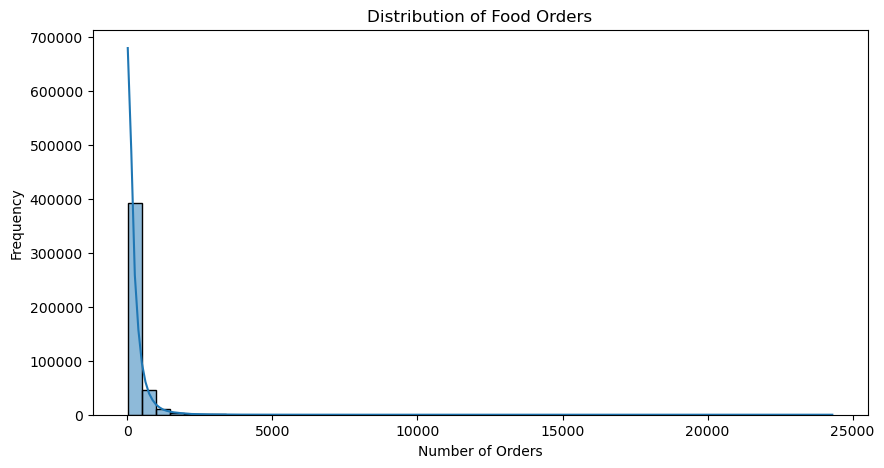

In [49]:
plt.figure(figsize=(10, 5))

sns.histplot(df["num_orders"], bins=50, kde=True)

plt.title("Distribution of Food Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Frequency")
plt.show()

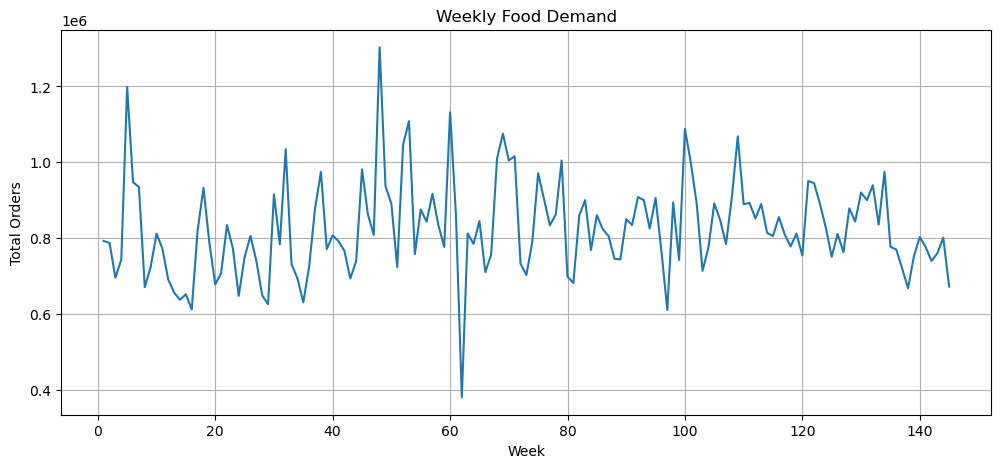

In [51]:
weekly_orders = df.groupby("week")["num_orders"].sum()

plt.figure(figsize=(12, 5))

plt.plot(weekly_orders.index, weekly_orders.values)

plt.title("Weekly Food Demand")
plt.xlabel("Week")
plt.ylabel("Total Orders")
plt.grid(True)

plt.show()

In [53]:
promotion_orders = df.groupby(
    "emailer_for_promotion"
)["num_orders"].mean()

print(promotion_orders)

emailer_for_promotion
0    229.262883
1    631.097544
Name: num_orders, dtype: float64


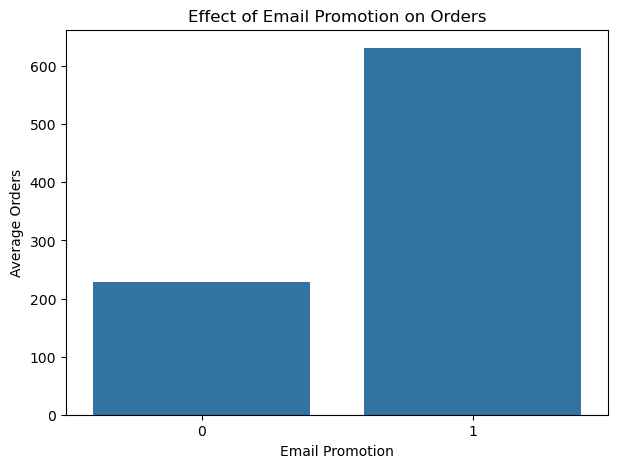

In [55]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=promotion_orders.index,
    y=promotion_orders.values
)

plt.title("Effect of Email Promotion on Orders")
plt.xlabel("Email Promotion")
plt.ylabel("Average Orders")

plt.show()

In [57]:
homepage_orders = df.groupby(
    "homepage_featured"
)["num_orders"].mean()

print(homepage_orders)

homepage_featured
0    221.050040
1    594.884786
Name: num_orders, dtype: float64


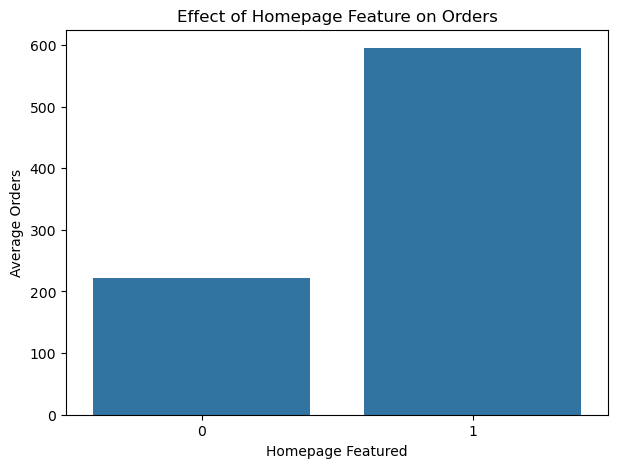

In [59]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=homepage_orders.index,
    y=homepage_orders.values
)

plt.title("Effect of Homepage Feature on Orders")
plt.xlabel("Homepage Featured")
plt.ylabel("Average Orders")

plt.show()

In [61]:
cuisine_orders = df.groupby(
    "cuisine"
)["num_orders"].mean().sort_values(ascending=False)

print(cuisine_orders)

cuisine
Italian        359.347830
Thai           276.423411
Indian         229.039037
Continental    164.545348
Name: num_orders, dtype: float64


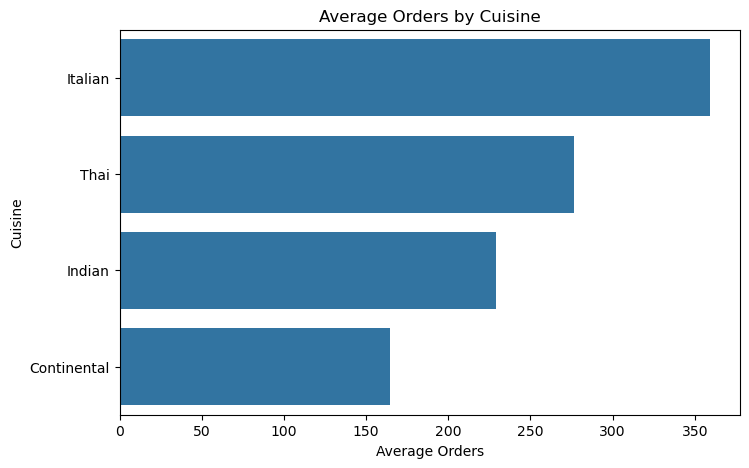

In [64]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=cuisine_orders.values,
    y=cuisine_orders.index
)

plt.title("Average Orders by Cuisine")
plt.xlabel("Average Orders")
plt.ylabel("Cuisine")

plt.show()

In [66]:
category_orders = df.groupby(
    "category"
)["num_orders"].mean().sort_values(ascending=False)

print(category_orders)

category
Rice Bowl       624.822288
Sandwich        529.776276
Salad           383.218460
Beverages       316.526116
Extras          293.834169
Pizza           222.817309
Other Snacks    162.234691
Starters        155.276110
Seafood         100.895898
Fish             85.595268
Soup             82.023353
Desert           66.250905
Pasta            59.137142
Biryani          30.651402
Name: num_orders, dtype: float64


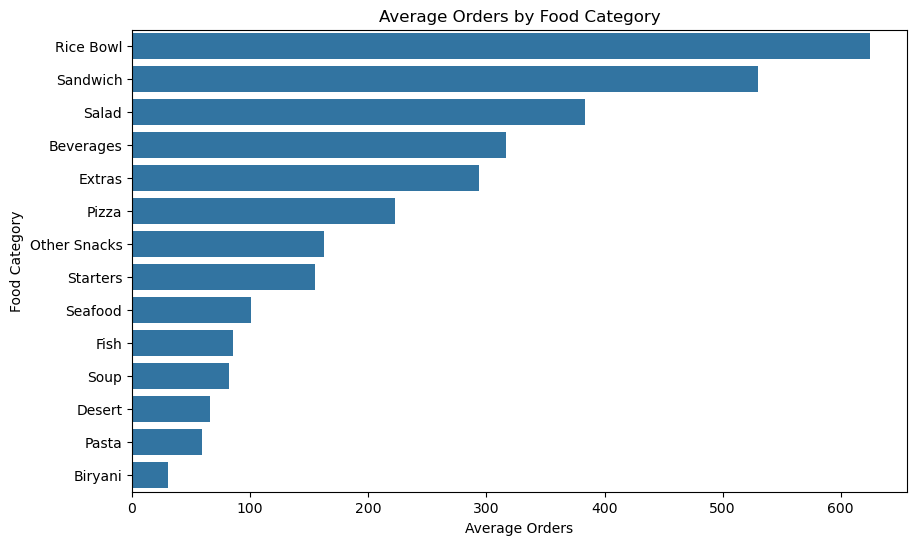

In [68]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_orders.values,
    y=category_orders.index
)

plt.title("Average Orders by Food Category")
plt.xlabel("Average Orders")
plt.ylabel("Food Category")

plt.show()

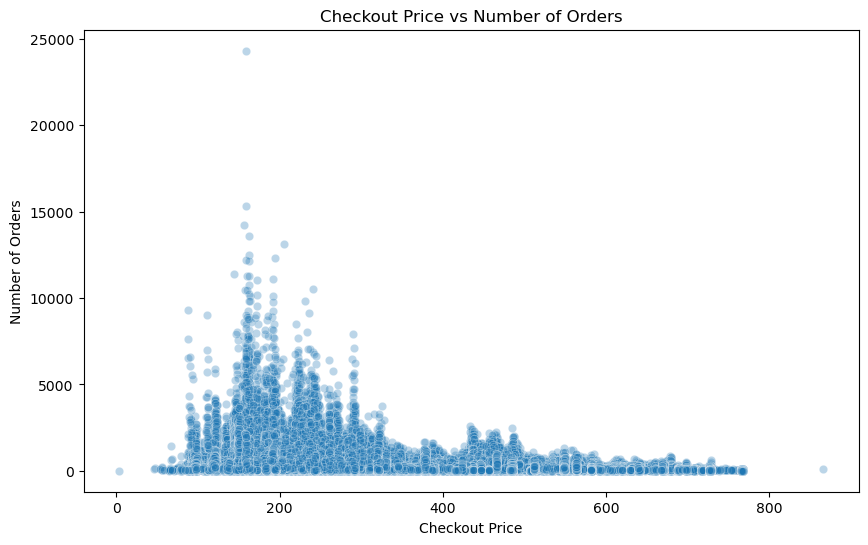

In [70]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="checkout_price",
    y="num_orders",
    alpha=0.3
)

plt.title("Checkout Price vs Number of Orders")
plt.xlabel("Checkout Price")
plt.ylabel("Number of Orders")

plt.show()

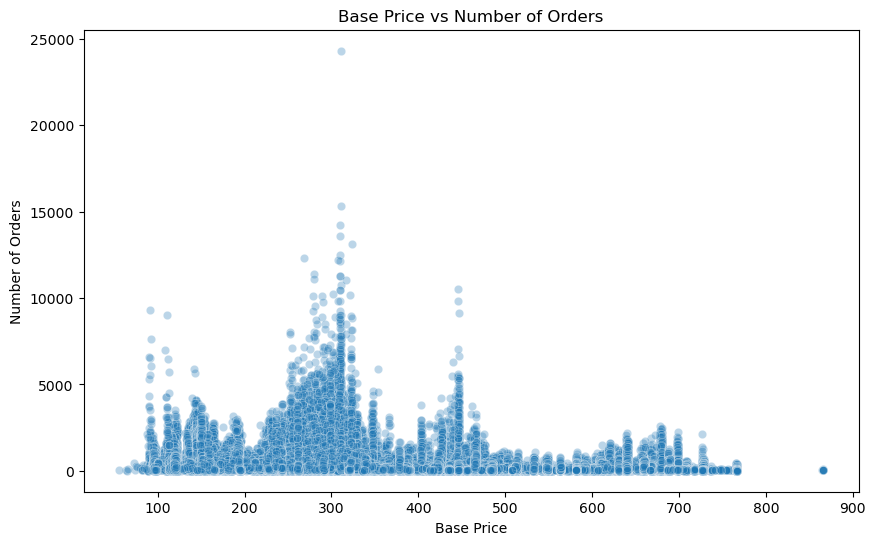

In [73]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="base_price",
    y="num_orders",
    alpha=0.3
)

plt.title("Base Price vs Number of Orders")
plt.xlabel("Base Price")
plt.ylabel("Number of Orders")

plt.show()

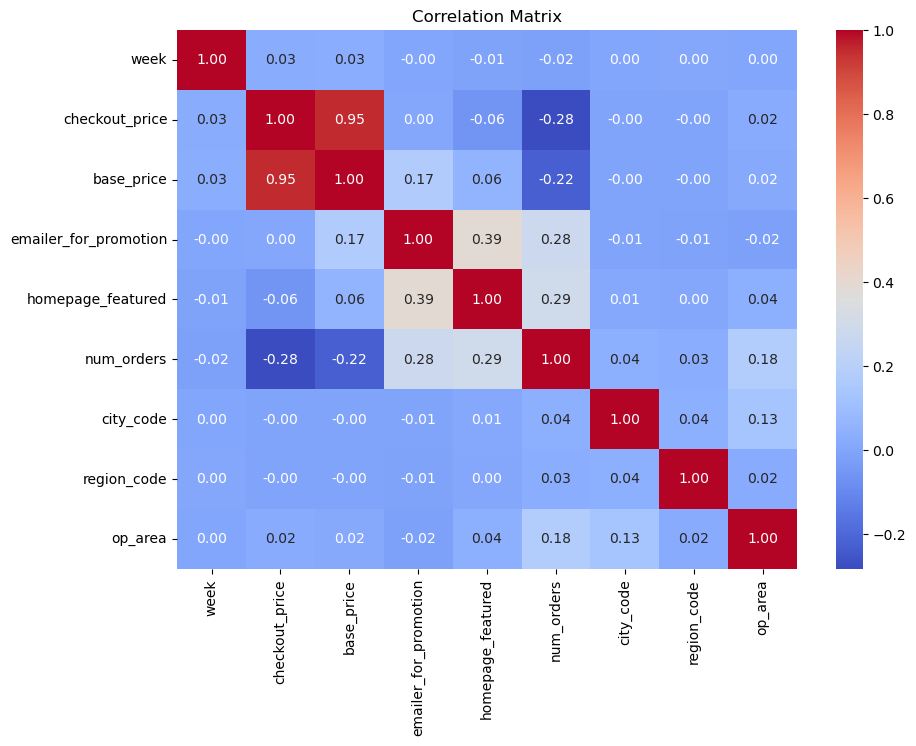

In [75]:
numeric_cols = [
    "week",
    "checkout_price",
    "base_price",
    "emailer_for_promotion",
    "homepage_featured",
    "num_orders",
    "city_code",
    "region_code",
    "op_area"
]

correlation = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [77]:
df["discount"] = df["base_price"] - df["checkout_price"]

In [79]:
df["discount_percent"] = (
    (df["base_price"] - df["checkout_price"])
    / df["base_price"]
) * 100

In [81]:
df["price_ratio"] = (
    df["checkout_price"] / df["base_price"]
)

In [83]:
df[
    [
        "base_price",
        "checkout_price",
        "discount",
        "discount_percent",
        "price_ratio"
    ]
].head()

,base_price,checkout_price,discount,discount_percent,price_ratio
0,152.29,136.83,15.46,10.151684,0.898483
1,135.83,136.83,-1.00,-0.736214,1.007362
2,135.86,134.86,1.00,0.736052,0.992639
3,437.53,339.50,98.03,22.405321,0.775947
4,242.50,243.50,-1.00,-0.412371,1.004124


In [85]:
y = df["num_orders"]

In [87]:
features = [
    "week",
    "center_id",
    "meal_id",
    "checkout_price",
    "base_price",
    "emailer_for_promotion",
    "homepage_featured",
    "city_code",
    "region_code",
    "op_area",
    "discount",
    "discount_percent",
    "price_ratio"
]

X = df[features]

In [89]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (456548, 13)
y Shape: (456548,)


In [91]:
df[["center_id", "meal_id"]].dtypes

center_id    int64
meal_id      int64
dtype: object

In [93]:
from sklearn.preprocessing import LabelEncoder

le_category = LabelEncoder()
le_cuisine = LabelEncoder()
le_center_type = LabelEncoder()

df["category_encoded"] = le_category.fit_transform(
    df["category"].astype(str)
)

df["cuisine_encoded"] = le_cuisine.fit_transform(
    df["cuisine"].astype(str)
)

df["center_type_encoded"] = le_center_type.fit_transform(
    df["center_type"].astype(str)
)

In [97]:
features = [
    "week",
    "center_id",
    "meal_id",
    "checkout_price",
    "base_price",
    "emailer_for_promotion",
    "homepage_featured",
    "city_code",
    "region_code",
    "op_area",
    "discount",
    "discount_percent",
    "price_ratio",
    "category_encoded",
    "cuisine_encoded",
    "center_type_encoded"
]

X = df[features]
y = df["num_orders"]

In [99]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (456548, 16)
Target: (456548,)


In [101]:
print("Minimum Week:", df["week"].min())
print("Maximum Week:", df["week"].max())

Minimum Week: 1
Maximum Week: 145


In [103]:
cutoff_week = int(df["week"].quantile(0.80))

print("Cutoff Week:", cutoff_week)

Cutoff Week: 118


In [105]:
train_data = df[df["week"] <= cutoff_week]
val_data = df[df["week"] > cutoff_week]

print("Training Data:", train_data.shape)
print("Validation Data:", val_data.shape)

Training Data: (367916, 21)
Validation Data: (88632, 21)


In [107]:
X_train = train_data[features]
X_val = val_data[features]

y_train = train_data["num_orders"]
y_val = val_data["num_orders"]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

X_train: (367916, 16)
X_val: (88632, 16)


In [109]:
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

In [111]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()

lr.fit(X_train, y_train_log)

pred_lr_log = lr.predict(X_val)

pred_lr = np.expm1(pred_lr_log)

pred_lr = np.maximum(pred_lr, 0)

In [113]:
mae_lr = mean_absolute_error(y_val, pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_val, pred_lr)
)

r2_lr = r2_score(y_val, pred_lr)

print("Linear Regression")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R2  :", r2_lr)

Linear Regression
MAE : 164.55637765706112
RMSE: 327.3354832419596
R2  : 0.20496692075123868


In [115]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train_log)

pred_rf_log = rf.predict(X_val)

pred_rf = np.expm1(pred_rf_log)

pred_rf = np.maximum(pred_rf, 0)

In [117]:
mae_rf = mean_absolute_error(y_val, pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_val, pred_rf)
)

r2_rf = r2_score(y_val, pred_rf)

print("Random Forest")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

Random Forest
MAE : 88.32148555393874
RMSE: 196.4786961146577
R2  : 0.7135624419005021


In [119]:
!pip install xgboost -q

In [121]:
from xgboost import XGBRegressor

In [123]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [125]:
xgb.fit(X_train, y_train_log)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

In [127]:
pred_xgb_log = xgb.predict(X_val)

pred_xgb = np.expm1(pred_xgb_log)

pred_xgb = np.maximum(pred_xgb, 0)

In [129]:
mae_xgb = mean_absolute_error(y_val, pred_xgb)

rmse_xgb = np.sqrt(
    mean_squared_error(y_val, pred_xgb)
)

r2_xgb = r2_score(y_val, pred_xgb)

print("XGBoost")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2  :", r2_xgb)

XGBoost
MAE : 86.92747548272307
RMSE: 203.5173840217763
R2  : 0.6926720555263182


In [131]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae_lr,
        mae_rf,
        mae_xgb
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_xgb
    ],
    "R2": [
        r2_lr,
        r2_rf,
        r2_xgb
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,164.556378,327.335483,0.204967
1,Random Forest,88.321486,196.478696,0.713562
2,XGBoost,86.927475,203.517384,0.692672


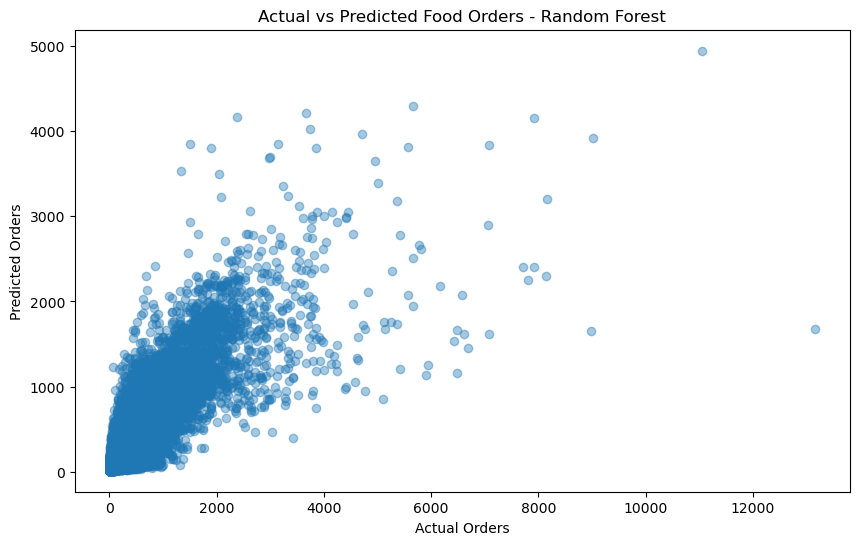

In [133]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_val,
    pred_rf,
    alpha=0.4
)

plt.xlabel("Actual Orders")
plt.ylabel("Predicted Orders")
plt.title("Actual vs Predicted Food Orders - Random Forest")

plt.show()

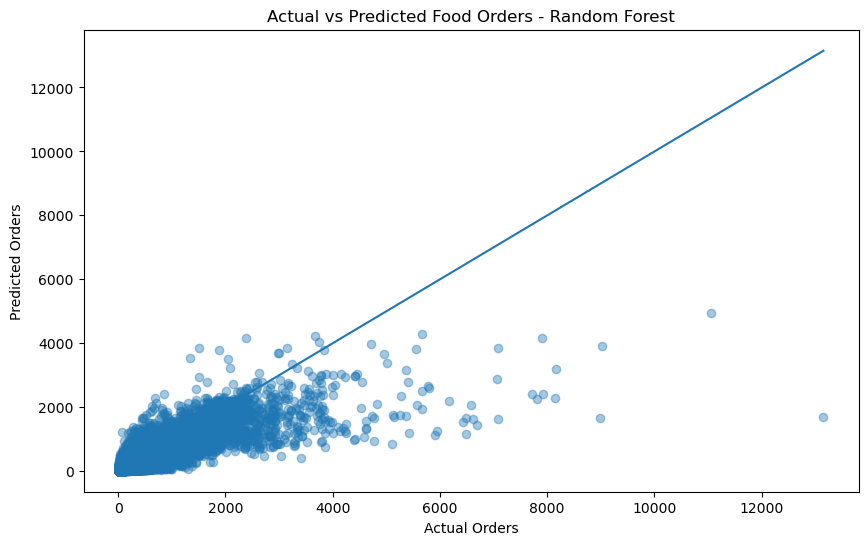

In [135]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_val,
    pred_rf,
    alpha=0.4
)

min_value = min(y_val.min(), pred_rf.min())
max_value = max(y_val.max(), pred_rf.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value]
)

plt.xlabel("Actual Orders")
plt.ylabel("Predicted Orders")
plt.title("Actual vs Predicted Food Orders - Random Forest")

plt.show()

In [137]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
3,checkout_price,0.262393
13,category_encoded,0.198043
4,base_price,0.081936
14,cuisine_encoded,0.081473
9,op_area,0.080990
0,week,0.070964
2,meal_id,0.034047
1,center_id,0.033781
15,center_type_encoded,0.025299
7,city_code,0.025103


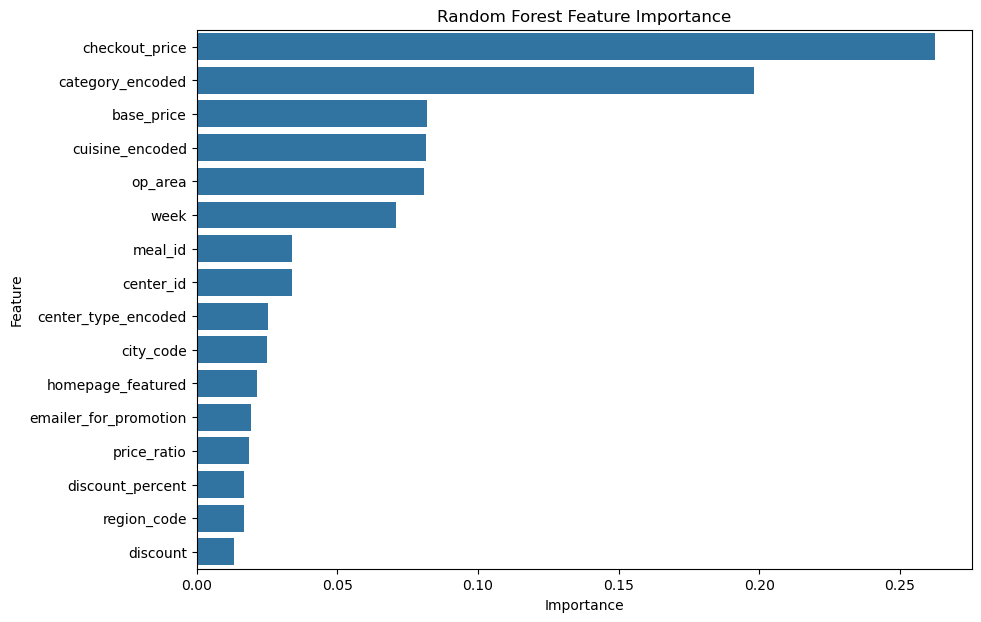

In [139]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [141]:
comparison = pd.DataFrame({
    "Actual Orders": y_val.values,
    "Predicted Orders": pred_rf
})

comparison.head(20)

,Actual Orders,Predicted Orders
0,123,94.982025
1,107,165.686793
2,149,141.808704
3,14,22.107872
4,55,79.428009
5,26,33.076185
6,202,233.704878
7,324,230.588252
8,405,346.443454
9,13,82.563629


In [143]:
comparison["Predicted Orders"] = comparison["Predicted Orders"].round(0)

comparison.head(20)

,Actual Orders,Predicted Orders
0,123,95.0
1,107,166.0
2,149,142.0
3,14,22.0
4,55,79.0
5,26,33.0
6,202,234.0
7,324,231.0
8,405,346.0
9,13,83.0


In [145]:
comparison["Recommended Preparation"] = (
    comparison["Predicted Orders"] * 1.05
).round()

In [147]:
comparison.head(10)

,Actual Orders,Predicted Orders,Recommended Preparation
0,123,95.0,100.0
1,107,166.0,174.0
2,149,142.0,149.0
3,14,22.0,23.0
4,55,79.0,83.0
5,26,33.0,35.0
6,202,234.0,246.0
7,324,231.0,243.0
8,405,346.0,363.0
9,13,83.0,87.0


In [149]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
3,checkout_price,0.262393
13,category_encoded,0.198043
4,base_price,0.081936
14,cuisine_encoded,0.081473
9,op_area,0.080990
0,week,0.070964
2,meal_id,0.034047
1,center_id,0.033781
15,center_type_encoded,0.025299
7,city_code,0.025103


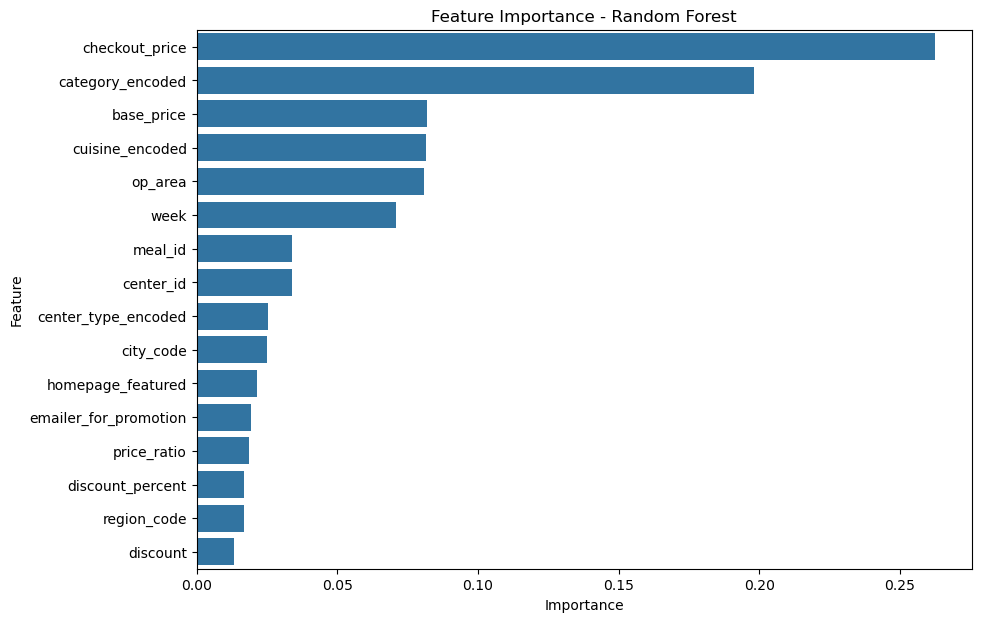

In [151]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [153]:
X_full = df[features]
y_full = df["num_orders"]

y_full_log = np.log1p(y_full)

final_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_full, y_full_log)

print("Final Random Forest Model Trained Successfully!")

Final Random Forest Model Trained Successfully!


In [155]:
test_df = test.merge(
    meal,
    on="meal_id",
    how="left"
)

test_df = test_df.merge(
    center,
    on="center_id",
    how="left"
)

In [157]:
test_df["discount"] = (
    test_df["base_price"] - test_df["checkout_price"]
)

test_df["discount_percent"] = (
    (test_df["base_price"] - test_df["checkout_price"])
    / test_df["base_price"]
) * 100

test_df["price_ratio"] = (
    test_df["checkout_price"] / test_df["base_price"]
)

In [159]:
test_df["category_encoded"] = le_category.transform(
    test_df["category"].astype(str)
)

test_df["cuisine_encoded"] = le_cuisine.transform(
    test_df["cuisine"].astype(str)
)

test_df["center_type_encoded"] = le_center_type.transform(
    test_df["center_type"].astype(str)
)

In [161]:
X_test = test_df[features]

test_pred_log = final_model.predict(X_test)

test_predictions = np.expm1(test_pred_log)

test_predictions = np.maximum(test_predictions, 0)

In [163]:
test_predictions[:10]

array([ 98.79343095,  80.99202541, 132.81614306,  57.90301491,
        58.85334975, 206.07151043, 277.0545457 , 211.01728703,
        90.27826755, 141.02608764])

In [165]:
final_predictions = pd.DataFrame({
    "id": test_df["id"],
    "predicted_orders": test_predictions.round(0)
})

final_predictions.head(10)

,id,predicted_orders
0,1028232,99.0
1,1127204,81.0
2,1212707,133.0
3,1082698,58.0
4,1400926,59.0
5,1284113,206.0
6,1197966,277.0
7,1132739,211.0
8,1057981,90.0
9,1095932,141.0


In [167]:
final_predictions.to_csv(
    "food_demand_predictions.csv",
    index=False
)

print("Prediction file created successfully!")

Prediction file created successfully!


In [169]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": final_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
3,checkout_price,0.256635
13,category_encoded,0.199437
14,cuisine_encoded,0.085282
9,op_area,0.084642
4,base_price,0.077421
0,week,0.072738
2,meal_id,0.035386
1,center_id,0.033008
15,center_type_encoded,0.026961
7,city_code,0.025126


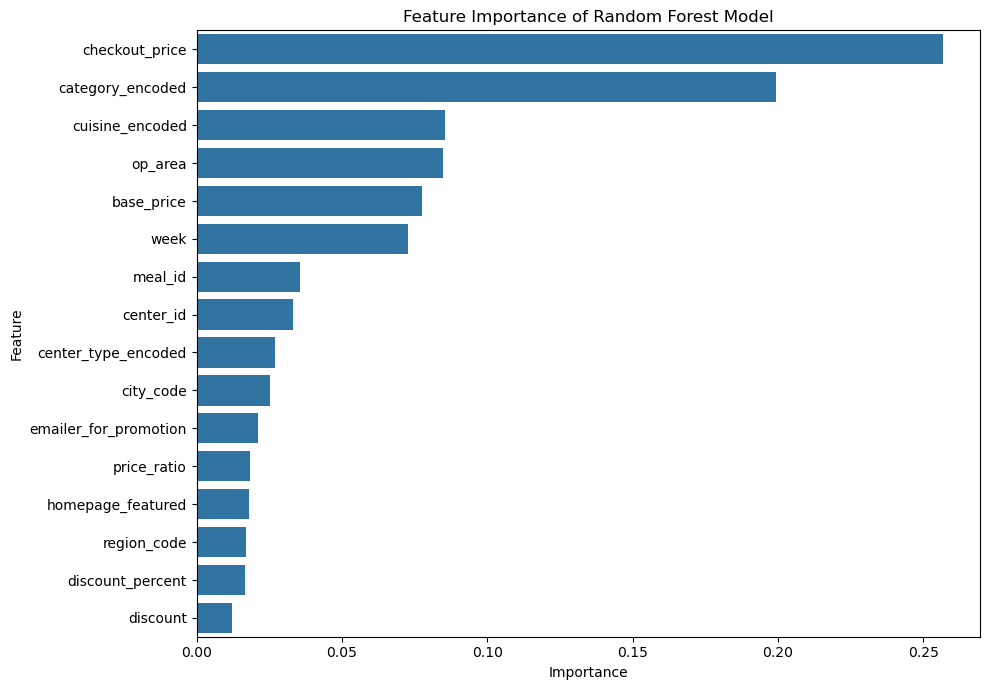

In [171]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance of Random Forest Model")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

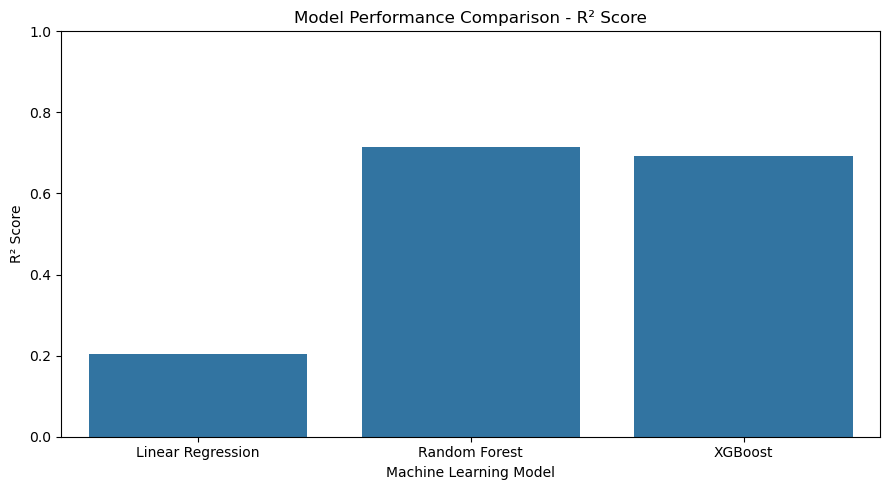

In [173]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=results,
    x="Model",
    y="R2"
)

plt.title("Model Performance Comparison - R² Score")
plt.xlabel("Machine Learning Model")
plt.ylabel("R² Score")

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

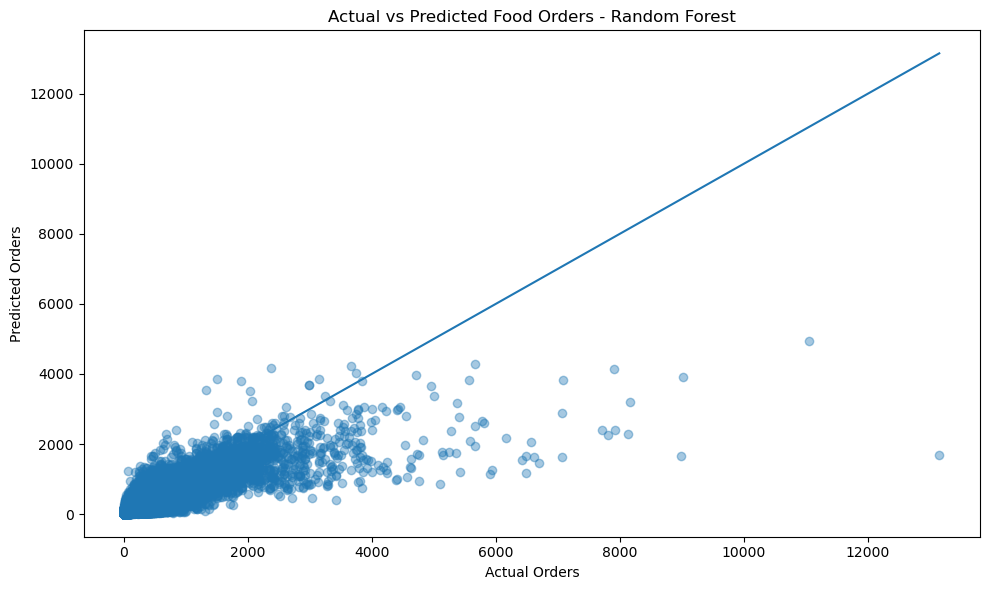

In [175]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_val,
    pred_rf,
    alpha=0.4
)

min_value = min(y_val.min(), pred_rf.min())
max_value = max(y_val.max(), pred_rf.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value]
)

plt.xlabel("Actual Orders")
plt.ylabel("Predicted Orders")
plt.title("Actual vs Predicted Food Orders - Random Forest")

plt.tight_layout()
plt.show()

In [177]:
final_predictions.shape

(32573, 2)

In [179]:
final_predictions.head(10)

,id,predicted_orders
0,1028232,99.0
1,1127204,81.0
2,1212707,133.0
3,1082698,58.0
4,1400926,59.0
5,1284113,206.0
6,1197966,277.0
7,1132739,211.0
8,1057981,90.0
9,1095932,141.0


In [181]:
final_predictions.describe()

,id,predicted_orders
count,3.257300e+04,32573.000000
mean,1.248476e+06,228.591195
std,1.441580e+05,362.632356
min,1.000085e+06,14.000000
25%,1.123969e+06,51.000000
50%,1.247296e+06,117.000000
75%,1.372971e+06,255.000000
max,1.499996e+06,6082.000000


# Project Workflow

Historical Food Demand Data
↓
Data Collection
↓
Data Cleaning
↓
Data Integration
↓
Exploratory Data Analysis
↓
Feature Engineering
↓
Categorical Encoding
↓
Time-Based Train/Validation Split
↓
Machine Learning Models
↓
Linear Regression
↓
Random Forest
↓
XGBoost
↓
Model Evaluation
↓
Best Model Selection
↓
Future Demand Prediction
↓
Inventory & Food Preparation Planning

## Conclusion

This project developed a machine learning-based food demand prediction system using historical food order data. The dataset was analysed using exploratory data analysis and enhanced through feature engineering.

Three regression models were evaluated: Linear Regression, Random Forest Regressor, and XGBoost Regressor.

Among the evaluated models, Random Forest achieved the best overall performance with an R² score of 0.714 and an RMSE of 196.48. Therefore, Random Forest was selected as the final model.

The final model was used to predict future food demand. These predictions can help food-service businesses improve food preparation, inventory planning, reduce food wastage, and avoid stock shortages.

The project demonstrates how machine learning can be applied to real-world demand forecasting and operational decision-making.

## Future Scope

1. Integration with real-time restaurant order data.
2. Incorporation of weather information.
3. Addition of holidays and festival information.
4. Use of advanced time-series forecasting models.
5. Development of a web-based prediction dashboard.
6. Integration with restaurant inventory management systems.
7. Real-time demand alerts for high and low demand.
8. Dynamic inventory recommendations based on predicted demand.

## Limitations

1. The dataset does not contain detailed customer-level information.
2. External factors such as weather and festivals are not included.
3. Unexpected events may affect actual food demand.
4. The model is trained on historical patterns and may not fully capture sudden changes in demand.
5. Real-time restaurant/POS integration is not implemented.